# Processing the data

Continuing with the example from the [previous chapter](https://huggingface.co/course/chapter2), here is how we would train a sequence classifier on one batch:

In [1]:
import torch

from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer

# set checkpoint:
checkpoint = "bert-base-uncased"

# load tokenizer:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# load model:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)


sequences = [
    "I've been waiting for a HuggingFace course my whole life.",
    "This course is amazing!",
]

batch = tokenizer(sequences, padding=True, truncation=True, return_tensors="pt")

# assign labels:
batch["labels"] = torch.tensor([1, 1])

optimizer = AdamW(model.parameters())
loss = model(**batch).loss
loss.backward()
optimizer.step()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Of course, just training the model on two sentences is not going to yield very good results. To get better results, you will need to prepare a bigger dataset.

In this section we will use as an example the MRPC (Microsoft Research Paraphrase Corpus) dataset, introduced in a paper by William B. Dolan and Chris Brockett. The dataset consists of 5,801 pairs of sentences, with a label indicating if they are paraphrases or not (i.e., if both sentences mean the same thing). We’ve selected it for this chapter because it’s a small dataset, so it’s easy to experiment with training on it.

## Loading a dataset from the Hub

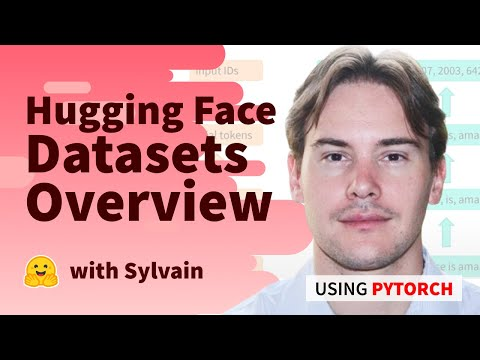

In [2]:
from IPython.display import YouTubeVideo

YouTubeVideo("_BZearw7f0w", width=800, height=450)

The Hub doesn’t just contain models; it also has multiple datasets in lots of different languages. You can browse the datasets [here](https://huggingface.co/datasets), and we recommend you try to load and process a new dataset once you have gone through this section (see the general documentation [here](https://huggingface.co/docs/datasets/loading)). But for now, let’s focus on the MRPC dataset! This is one of the 10 datasets composing the [GLUE benchmark](https://gluebenchmark.com/), which is an academic benchmark that is used to measure the performance of ML models across 10 different text classification tasks.

The 🤗 Datasets library provides a very simple command to download and cache a dataset on the Hub. We can download the MRPC dataset like this:

> 💡 Additional Resources: For more dataset loading techniques and examples, check out the [🤗 Datasets documentation](https://huggingface.co/docs/datasets/).

In [5]:
from datasets import load_dataset

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")
raw_datasets

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

mrpc/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  649kB            

mrpc/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mrpc/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 75.7kB            

mrpc/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

mrpc/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

As you can see, we get a `DatasetDict` object which contains the training set, the validation set, and the test set. Each of those contains several columns (`sentence1`, `sentence2`, `label`, and `idx`) and a variable number of rows, which are the number of elements in each set (so, there are 3,668 pairs of sentences in the training set, 408 in the validation set, and 1,725 in the test set).

> This command downloads and caches the dataset, by default in `~/.cache/huggingface/datasets`. Recall from Chapter 2 that you can customize your cache folder by setting the `HF_HOME` environment variable.

We can access each pair of sentences in our `raw_datasets` object by indexing, like with a dictionary:

In [6]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

We can see the labels are already integers, so we won’t have to do any preprocessing there. To know which integer corresponds to which label, we can inspect the `features` of our `raw_train_dataset`. This will tell us the type of each column:

In [7]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

Behind the scenes, `label` is of type `ClassLabel`, and the mapping of integers to label name is stored in the `names` folder. `0` corresponds to `not_equivalent`, and `1` corresponds to `equivalent`.

> ✏️ Try it out! Look at element 15 of the training set and element 87 of the validation set. What are their labels?

## Preprocessing a dataset

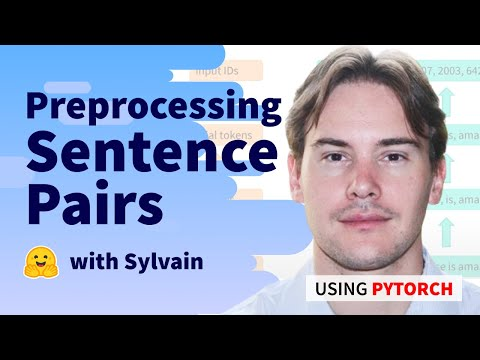

In [8]:
from IPython.display import YouTubeVideo

YouTubeVideo("0u3ioSwev3s", width=800, height=450)

To preprocess the dataset, we need to convert the text to numbers the model can make sense of. As you saw in the [previous chapter](https://huggingface.co/course/chapter2), this is done with a tokenizer. We can feed the tokenizer one sentence or a list of sentences, so we can directly tokenize all the first sentences and all the second sentences of each pair like this:

In [17]:
from transformers import AutoTokenizer

checkpoint = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [22]:
tokenized_sentences_1 = tokenizer(list(raw_datasets["train"]["sentence1"]))
tokenized_sentences_2 = tokenizer(list(raw_datasets["train"]["sentence2"]))